In [19]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All required libraries imported successfully!")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = tfidf_matrix
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training and testing data prepared successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

All required libraries imported successfully!
Training and testing data prepared successfully!
Training samples: 1987
Testing samples: 497


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/sama/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/home/sama/Desktop/Intelligent-Resume-Screening-System/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/sama/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to /home/sama/nltk_data...


In [3]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
/home/sama/Desktop/Intelligent-Resume-Screening-System/notebooks


In [1]:
import pandas as pd

# Load the Resume Dataset
df = pd.read_csv("../dataset/Resume.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2484, 4)


In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())

Column names:
['ID', 'Resume_str', 'Resume_html', 'Category']

First 5 records:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nResume categories:")
print(df["Category"].value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB
None

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR             

In [5]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

/home/sama/Desktop/Intelligent-Resume-Screening-System/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/sama/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to /home/sama/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/sama/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sama/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Function to clean resume text
def preprocess_text(text):
    # Convert text to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and very short words
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    # Join words back together
    return " ".join(tokens)

# Apply preprocessing
df["clean_resume"] = df["Resume_str"].apply(preprocess_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


In [7]:
print("ORIGINAL RESUME:")
print(df["Resume_str"].iloc[0][:1000])

print("\n" + "=" * 80 + "\n")

print("CLEANED RESUME:")
print(df["clean_resume"].iloc[0][:1000])

ORIGINAL RESUME:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory co

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert cleaned resumes into TF-IDF vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_resume"])

print("TF-IDF feature extraction completed successfully!")
print("Number of resumes:", tfidf_matrix.shape[0])
print("Number of TF-IDF features:", tfidf_matrix.shape[1])

TF-IDF feature extraction completed successfully!
Number of resumes: 2484
Number of TF-IDF features: 5000


In [9]:
job_description = """
We are looking for a Python Developer with strong programming skills.
The candidate should have experience with Python, machine learning,
data analysis, pandas, NumPy, scikit-learn, SQL, and data visualization.
Knowledge of software development, problem solving, and teamwork is required.
Experience with artificial intelligence and natural language processing is a plus.
"""

print("Job description created successfully!")
print(job_description)

Job description created successfully!

We are looking for a Python Developer with strong programming skills.
The candidate should have experience with Python, machine learning,
data analysis, pandas, NumPy, scikit-learn, SQL, and data visualization.
Knowledge of software development, problem solving, and teamwork is required.
Experience with artificial intelligence and natural language processing is a plus.



In [10]:
clean_job_description = preprocess_text(job_description)

print("Cleaned Job Description:")
print(clean_job_description)

Cleaned Job Description:
looking python developer strong programming skills candidate experience python machine learning data analysis pandas numpy scikit learn sql data visualization knowledge software development problem solving teamwork required experience artificial intelligence natural language processing plus


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Convert the job description into TF-IDF features
job_vector = tfidf_vectorizer.transform([clean_job_description])

# Calculate similarity between job description and every resume
similarity_scores = cosine_similarity(job_vector, tfidf_matrix)[0]

# Add relevance score to the dataset
df["relevance_score"] = similarity_scores * 100

print("Relevance scores calculated successfully!")
print("Number of resumes scored:", len(df))

Relevance scores calculated successfully!
Number of resumes scored: 2484


In [12]:
# Sort resumes from highest to lowest relevance
ranked_resumes = df.sort_values(
    by="relevance_score",
    ascending=False
).reset_index(drop=True)

# Display top 10 candidates
top_candidates = ranked_resumes[
    ["ID", "Category", "relevance_score"]
].head(10)

display(top_candidates)

,ID,Category,relevance_score
0,21156767,CONSULTANT,26.724606
1,12011623,ENGINEERING,23.715113
2,22946204,AUTOMOBILE,22.547695
3,62994611,AGRICULTURE,21.918764
4,18448085,AUTOMOBILE,20.782563
5,42156237,DIGITAL-MEDIA,19.482637
6,12144825,AVIATION,18.570041
7,28790806,AUTOMOBILE,18.277243
8,13385306,INFORMATION-TECHNOLOGY,18.203666
9,32985311,ENGINEERING,17.979199


In [13]:
# Important skills for the Python Developer job

required_skills = [
    "python",
    "machine learning",
    "data analysis",
    "pandas",
    "numpy",
    "scikit learn",
    "sql",
    "data visualization",
    "software development",
    "artificial intelligence",
    "natural language processing"
]

print("Required skills:")
for skill in required_skills:
    print("-", skill)

Required skills:
- python
- machine learning
- data analysis
- pandas
- numpy
- scikit learn
- sql
- data visualization
- software development
- artificial intelligence
- natural language processing


In [14]:
def calculate_skill_match(resume_text, skills):
    matched_skills = []

    for skill in skills:
        if skill.lower() in resume_text.lower():
            matched_skills.append(skill)

    match_percentage = (len(matched_skills) / len(skills)) * 100

    return match_percentage, matched_skills


# Calculate skill matching for every resume
skill_results = df["clean_resume"].apply(
    lambda text: calculate_skill_match(text, required_skills)
)

df["skill_match_percentage"] = skill_results.apply(lambda x: x[0])
df["matched_skills"] = skill_results.apply(lambda x: ", ".join(x[1]))

print("Skill matching completed successfully!")

Skill matching completed successfully!


In [15]:
skill_candidates = df.sort_values(
    by="skill_match_percentage",
    ascending=False
).reset_index(drop=True)

display(
    skill_candidates[
        ["ID", "Category", "skill_match_percentage", "matched_skills"]
    ].head(10)
)

,ID,Category,skill_match_percentage,matched_skills
0,18448085,AUTOMOBILE,63.636364,"python, data analysis, pandas, numpy, scikit l..."
1,62994611,AGRICULTURE,54.545455,"python, pandas, scikit learn, sql, data visual..."
2,12011623,ENGINEERING,54.545455,"python, machine learning, data analysis, panda..."
3,21156767,CONSULTANT,54.545455,"python, machine learning, data analysis, sql, ..."
4,50328713,ENGINEERING,45.454545,"python, machine learning, pandas, scikit learn..."
5,34317538,DESIGNER,45.454545,"data analysis, sql, data visualization, softwa..."
6,22946204,AUTOMOBILE,36.363636,"python, machine learning, data analysis, sql"
7,12144825,AVIATION,36.363636,"python, sql, software development, natural lan..."
8,12635195,INFORMATION-TECHNOLOGY,27.272727,"python, data analysis, software development"
9,11813872,AGRICULTURE,27.272727,"python, pandas, sql"


In [16]:
df["final_score"] = (
    0.6 * df["relevance_score"] +
    0.4 * df["skill_match_percentage"]
)

print("Final candidate scores calculated successfully!")

Final candidate scores calculated successfully!


In [17]:
final_ranked = df.sort_values(
    by="final_score",
    ascending=False
).reset_index(drop=True)

display(
    final_ranked[
        [
            "ID",
            "Category",
            "relevance_score",
            "skill_match_percentage",
            "matched_skills",
            "final_score"
        ]
    ].head(10)
)

,ID,Category,relevance_score,skill_match_percentage,matched_skills,final_score
0,18448085,AUTOMOBILE,20.782563,63.636364,"python, data analysis, pandas, numpy, scikit l...",37.924083
1,21156767,CONSULTANT,26.724606,54.545455,"python, machine learning, data analysis, sql, ...",37.852945
2,12011623,ENGINEERING,23.715113,54.545455,"python, machine learning, data analysis, panda...",36.047250
3,62994611,AGRICULTURE,21.918764,54.545455,"python, pandas, scikit learn, sql, data visual...",34.969440
4,22946204,AUTOMOBILE,22.547695,36.363636,"python, machine learning, data analysis, sql",28.074071
5,12144825,AVIATION,18.570041,36.363636,"python, sql, software development, natural lan...",25.687479
6,50328713,ENGINEERING,8.326012,45.454545,"python, machine learning, pandas, scikit learn...",23.177425
7,34317538,DESIGNER,6.779522,45.454545,"data analysis, sql, data visualization, softwa...",22.249532
8,18067556,INFORMATION-TECHNOLOGY,16.819112,27.272727,"python, data analysis, sql",21.000558
9,11813872,AGRICULTURE,16.801818,27.272727,"python, pandas, sql",20.990181


In [18]:
final_ranked.to_csv(
    "../results/ranked_resumes.csv",
    index=False
)

print("Ranked results saved successfully!")
print("File: results/ranked_resumes.csv")

Ranked results saved successfully!
File: results/ranked_resumes.csv


In [20]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

classifier.fit(X_train, y_train)

print("Classification model trained successfully!")

Classification model trained successfully!


In [21]:
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Classification completed successfully!")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Classification completed successfully!
Model Accuracy: 66.40%


In [22]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print("Classification Report:")
print(report)

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.35      0.50      0.41        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.54      0.33      0.41        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.71      0.77        24
               BANKING       0.80      0.70      0.74        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.54      0.92      0.68        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.77      0.77      0.77        22
            CONSULTANT       0.50      0.22      0.30        23
              DESIGNER       0.86      0.86      0.86        21
         DIGITAL

!pip install matplotlib

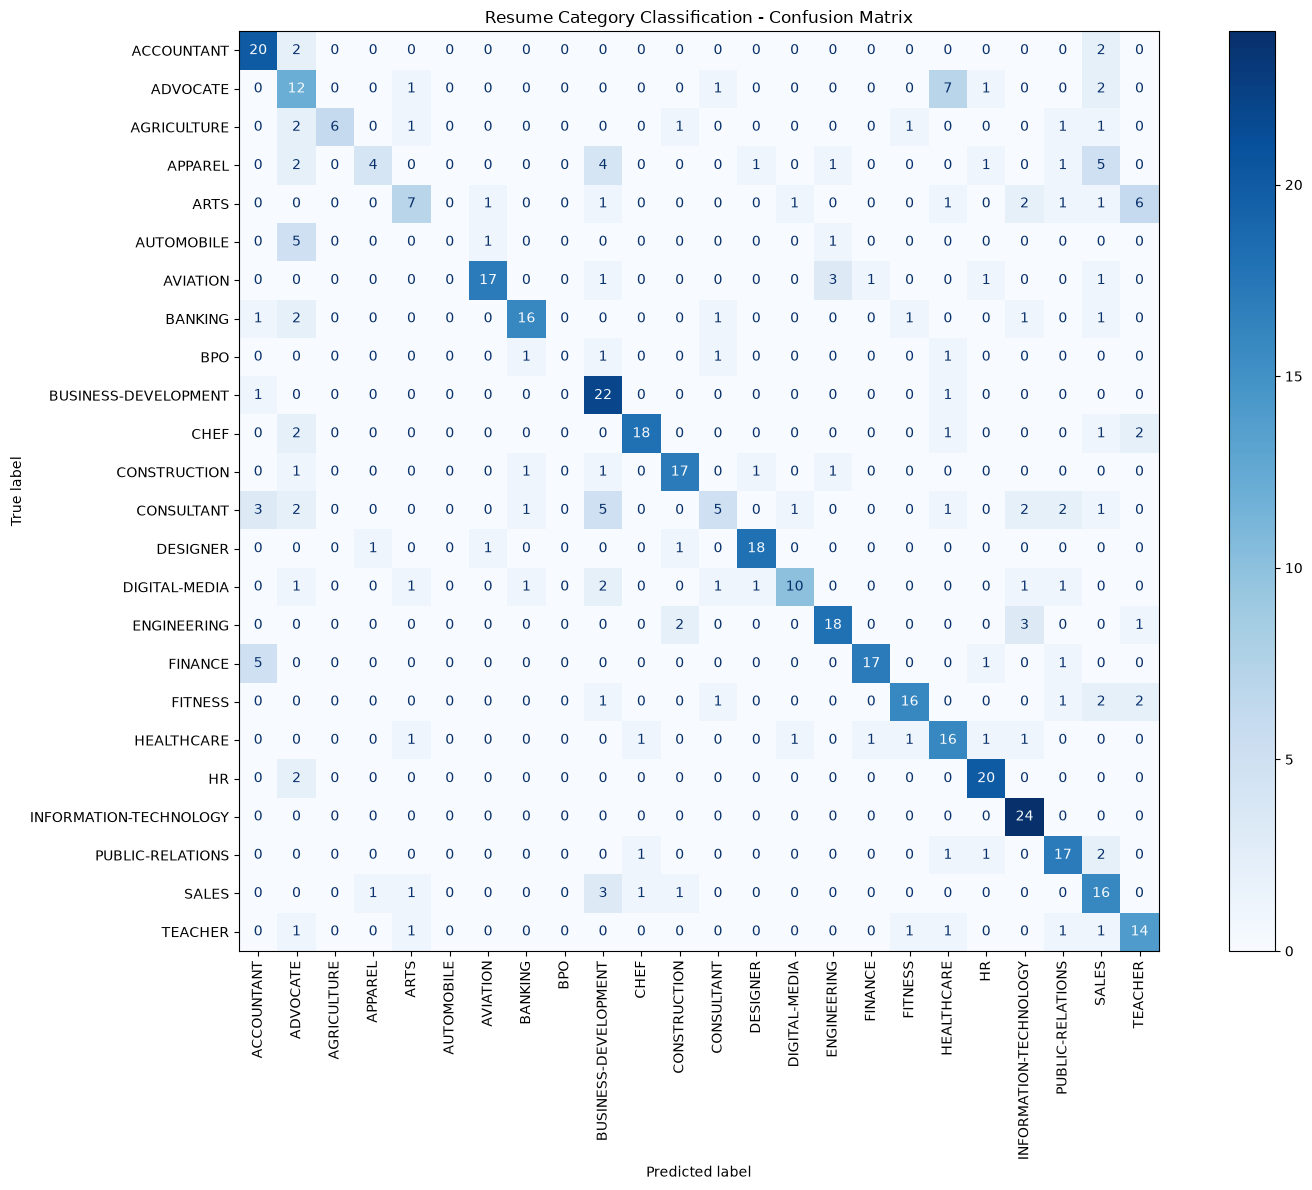

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=classifier.classes_
)

plt.figure(figsize=(16, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classifier.classes_
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    ax=plt.gca()
)

plt.title("Resume Category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
def screen_resume(resume_text):
    # Preprocess the new resume
    clean_text = preprocess_text(resume_text)

    # Convert resume into TF-IDF vector
    resume_vector = tfidf_vectorizer.transform([clean_text])

    # Calculate relevance score
    relevance = cosine_similarity(
        job_vector,
        resume_vector
    )[0][0] * 100

    # Calculate skill match
    skill_percentage, matched = calculate_skill_match(
        clean_text,
        required_skills
    )

    # Calculate final score
    final_score = (
        0.6 * relevance +
        0.4 * skill_percentage
    )

    return {
        "relevance_score": relevance,
        "skill_match_percentage": skill_percentage,
        "matched_skills": matched,
        "final_score": final_score
    }

print("Resume screening function created successfully!")

Resume screening function created successfully!


In [27]:
sample_resume = """
Python Developer with experience in Python programming and software development.
Skilled in machine learning, data analysis, pandas, NumPy, scikit-learn, SQL,
and data visualization. Experienced in developing machine learning models,
working with artificial intelligence and natural language processing.
Strong problem-solving and teamwork skills.
"""

result = screen_resume(sample_resume)

print("Resume Screening Result")
print("-" * 30)
print(f"Relevance Score: {result['relevance_score']:.2f}%")
print(f"Skill Match: {result['skill_match_percentage']:.2f}%")
print(f"Final Score: {result['final_score']:.2f}%")
print("Matched Skills:", ", ".join(result["matched_skills"]))

Resume Screening Result
------------------------------
Relevance Score: 83.57%
Skill Match: 100.00%
Final Score: 90.14%
Matched Skills: python, machine learning, data analysis, pandas, numpy, scikit learn, sql, data visualization, software development, artificial intelligence, natural language processing


In [28]:
weak_resume = """
Graphic Designer with experience in Adobe Photoshop, Illustrator,
UI design, logo design, branding, typography, and creative design.
Experienced in creating posters, brochures, social media graphics,
and visual content. Strong creativity and communication skills.
"""

weak_result = screen_resume(weak_resume)

print("Weak Resume Screening Result")
print("-" * 35)
print(f"Relevance Score: {weak_result['relevance_score']:.2f}%")
print(f"Skill Match: {weak_result['skill_match_percentage']:.2f}%")
print(f"Final Score: {weak_result['final_score']:.2f}%")
print("Matched Skills:", ", ".join(weak_result["matched_skills"]))

Weak Resume Screening Result
-----------------------------------
Relevance Score: 1.76%
Skill Match: 0.00%
Final Score: 1.06%
Matched Skills: 


!pip install streamlit

In [30]:
import pickle

with open("../results/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

with open("../results/classifier.pkl", "wb") as file:
    pickle.dump(classifier, file)

print("Model components saved successfully!")

Model components saved successfully!


In [31]:
with open("../results/required_skills.pkl", "wb") as file:
    pickle.dump(required_skills, file)

print("Required skills saved successfully!")

Required skills saved successfully!
